# Data Center Health AI: Exploratory Data Analysis & Feature Engineering
**Author:** Chaitanya Kiran  
**Domain:** AIOps / Infrastructure Telemetry Observability  
**Dataset:** Server Machine Dataset (SMD, Tsinghua University / OmniAnomaly)  
**Objective:** Analyze 38 high-density sensor metrics across enterprise cloud servers, investigate failure precursor drift, evaluate ground-truth anomaly distributions, and engineer zero-leakage temporal feature windows.

## 1. Environment Setup & Dependency Imports

In [1]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Add project root to sys.path
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.ml.model_registry import SMD_SENSOR_NAMES
print(f"Loaded {len(SMD_SENSOR_NAMES)} telemetry sensor definitions.")

2026-09-07 21:10:37 [INFO] [DataCenterHealthAI:load_champion_artifacts:51] - [InferenceEngine] Loaded champion model: RobustCovariance


2026-09-07 21:10:37 [INFO] [DataCenterHealthAI:load_champion_artifacts:57] - [InferenceEngine] Loaded feature scaler for machine-1-1


Loaded 38 telemetry sensor definitions.


## 2. Ingesting Raw SMD Telemetry & Anomaly Labels

In [2]:
import json
data_dir = project_root / 'data' / 'raw' / 'smd'
machine_id = 'machine-1-1'

train_path = data_dir / 'train' / f'{machine_id}.txt'
test_path = data_dir / 'test' / f'{machine_id}.txt'
label_path = data_dir / 'test_label' / f'{machine_id}.txt'

train_raw = np.loadtxt(train_path, delimiter=',')
test_raw = np.loadtxt(test_path, delimiter=',')
test_labels = np.loadtxt(label_path, delimiter=',').astype(int)

df_train = pd.DataFrame(train_raw, columns=SMD_SENSOR_NAMES)
df_test = pd.DataFrame(test_raw, columns=SMD_SENSOR_NAMES)
df_test['is_anomaly'] = test_labels

print(f"[DATASET AUDIT] {machine_id}")
print(f"- Train Partition Shape: {df_train.shape} (Nominal Healthy Baseline)")
print(f"- Test Partition Shape:  {df_test.shape} (Operational Telemetry with Failures)")
print(f"- Anomaly Labels Count:  {test_labels.sum()} / {len(test_labels)} ({test_labels.mean()*100:.2f}%)")
print(f"- Missing / Null Values: {df_train.isna().sum().sum()} (Train), {df_test.isna().sum().sum()} (Test)")

[DATASET AUDIT] machine-1-1
- Train Partition Shape: (28479, 38) (Nominal Healthy Baseline)
- Test Partition Shape:  (28479, 39) (Operational Telemetry with Failures)
- Anomaly Labels Count:  2694 / 28479 (9.46%)
- Missing / Null Values: 0 (Train), 0 (Test)


## 3. Sensor Taxonomy & Telemetry Summary Statistics

In [3]:
# Display summary stats for key vital sensors
key_sensors = [
    'CPU_Utilization_Pct', 'Load_Average_1m', 'Memory_Used_Pct',
    'Memory_Page_Faults_Sec', 'Disk_Write_IOPS', 'Temperature_Chassis_C'
]
display(df_train[key_sensors].describe().T)

,count,mean,std,min,25%,50%,75%,max
CPU_Utilization_Pct,28479.0,0.064195,0.056685,0.000000,0.032258,0.043011,0.086022,0.494624
Load_Average_1m,28479.0,0.000159,0.001287,0.000000,0.000000,0.000000,0.000122,0.140435
Memory_Used_Pct,28479.0,0.026628,0.016518,0.000000,0.013699,0.027397,0.041096,0.315068
Memory_Page_Faults_Sec,28479.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Disk_Write_IOPS,28479.0,0.061939,0.041517,0.010018,0.035129,0.047862,0.081109,0.369534
Temperature_Chassis_C,28479.0,0.050401,0.035044,0.008759,0.028015,0.036485,0.066020,0.311206


## 4. Visualizing Failure Precursor Drift & Anomaly Windows
In operational environments, failures are preceded by subtle drifts in CPU Wait I/O, paging rates, or memory starvation.

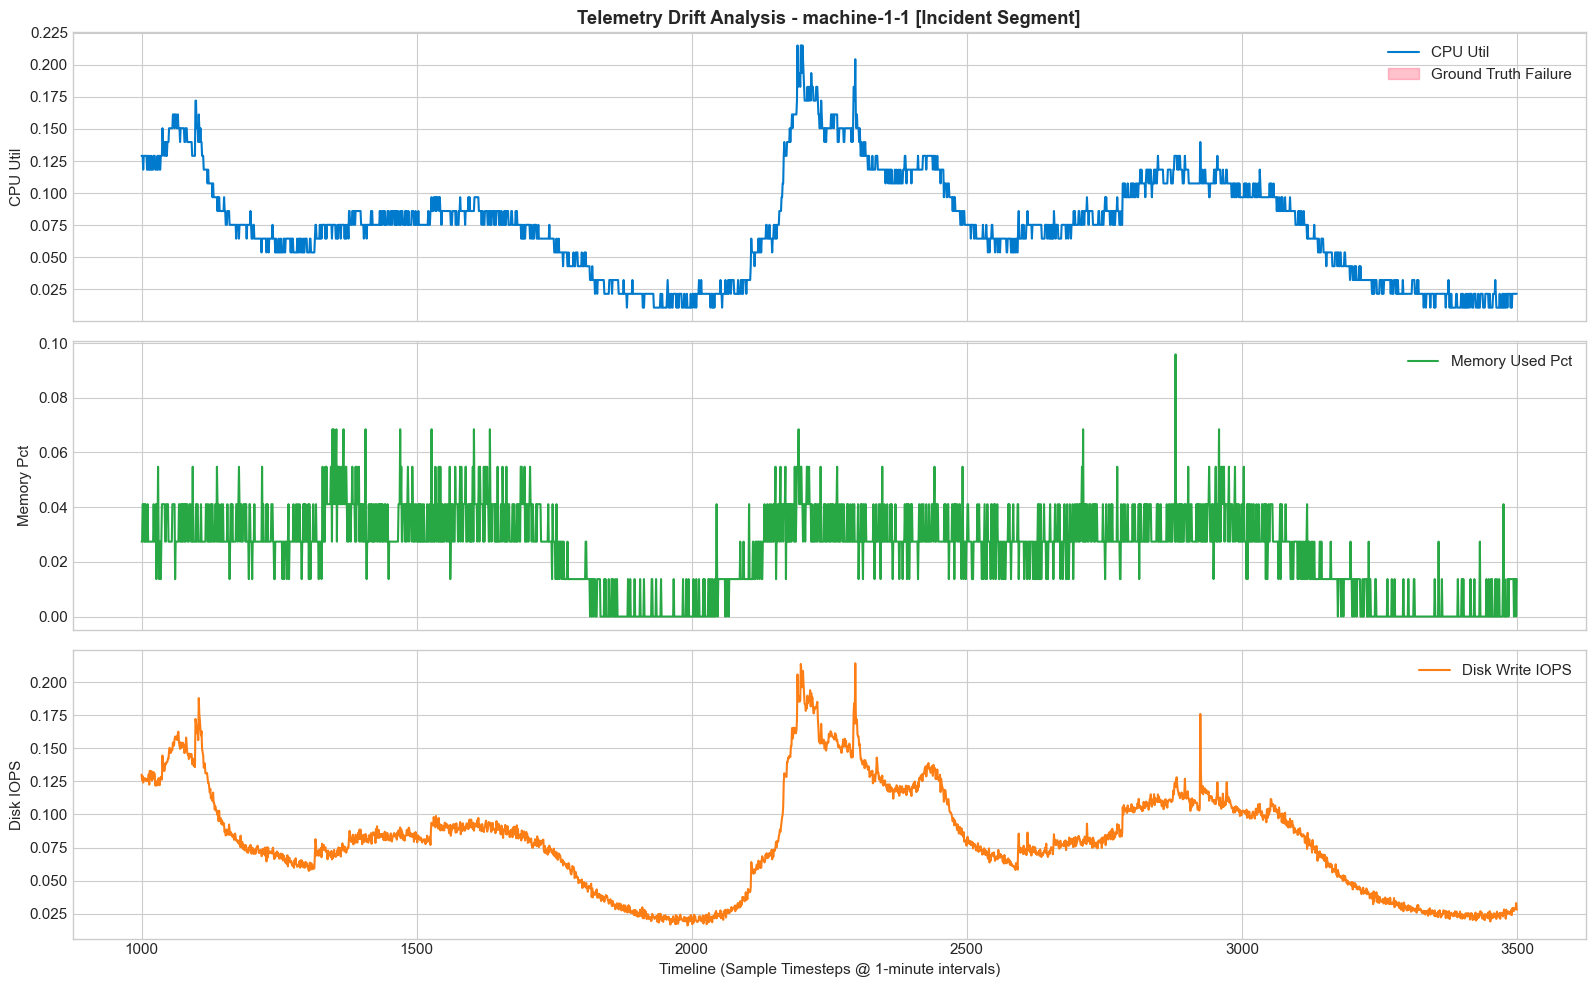

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Slice window around major anomaly incident
start_idx, end_idx = 1000, 3500
time_range = np.arange(start_idx, end_idx)
anomaly_mask = df_test['is_anomaly'].iloc[start_idx:end_idx] == 1

# 1. CPU Load
axes[0].plot(time_range, df_test['CPU_Utilization_Pct'].iloc[start_idx:end_idx], color='#007acc', label='CPU Util')
axes[0].fill_between(time_range, 0, 1, where=anomaly_mask, color='#ff385c', alpha=0.3, transform=axes[0].get_xaxis_transform(), label='Ground Truth Failure')
axes[0].set_ylabel('CPU Util')
axes[0].legend(loc='upper right')
axes[0].set_title(f'Telemetry Drift Analysis - {machine_id} [Incident Segment]', fontweight='bold')

# 2. Memory Utilization
axes[1].plot(time_range, df_test['Memory_Used_Pct'].iloc[start_idx:end_idx], color='#28a745', label='Memory Used Pct')
axes[1].fill_between(time_range, 0, 1, where=anomaly_mask, color='#ff385c', alpha=0.3, transform=axes[1].get_xaxis_transform())
axes[1].set_ylabel('Memory Pct')
axes[1].legend(loc='upper right')

# 3. Disk Activity
axes[2].plot(time_range, df_test['Disk_Write_IOPS'].iloc[start_idx:end_idx], color='#fd7e14', label='Disk Write IOPS')
axes[2].fill_between(time_range, 0, 1, where=anomaly_mask, color='#ff385c', alpha=0.3, transform=axes[2].get_xaxis_transform())
axes[2].set_ylabel('Disk IOPS')
axes[2].set_xlabel('Timeline (Sample Timesteps @ 1-minute intervals)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Cross-Sensor Correlation Heatmap
Observing multi-sensor coupling: high CPU utilization correlates with memory bus pressure and chassis fan speed.

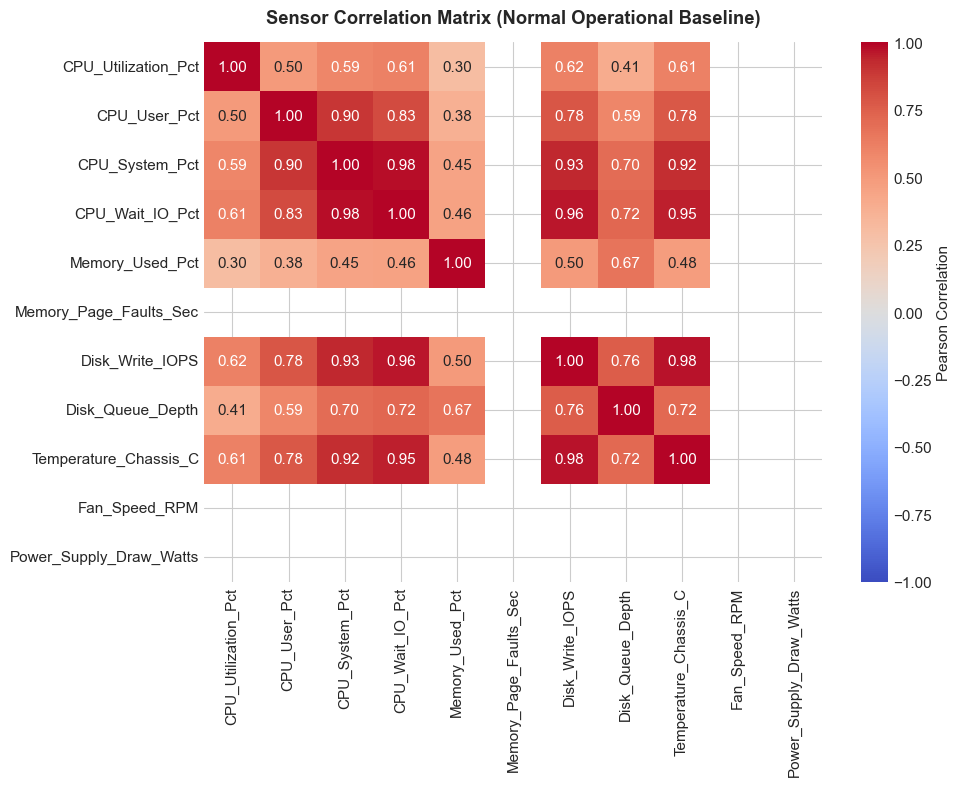

In [5]:
corr_sensors = [
    'CPU_Utilization_Pct', 'CPU_User_Pct', 'CPU_System_Pct', 'CPU_Wait_IO_Pct',
    'Memory_Used_Pct', 'Memory_Page_Faults_Sec', 'Disk_Write_IOPS', 'Disk_Queue_Depth',
    'Temperature_Chassis_C', 'Fan_Speed_RPM', 'Power_Supply_Draw_Watts'
]

corr_matrix = df_train[corr_sensors].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Sensor Correlation Matrix (Normal Operational Baseline)', fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

## 6. Processed Data Verification & Manifest Inspection

In [6]:
manifest_path = project_root / 'data' / 'processed' / 'data_processing_manifest.json'
if manifest_path.exists():
    with open(manifest_path, 'r', encoding='utf-8') as f:
        manifest = json.load(f)
    print("=== PROCESSED DATA MANIFEST PROOF ===")
    for k, v in manifest.items():
        print(f"{k:30s}: {v}")
else:
    print("Manifest not generated yet. Run export_processed_data.py.")

=== PROCESSED DATA MANIFEST PROOF ===
machine_id                    : machine-1-1
raw_train_samples             : 24149
raw_test_samples              : 28479
sensors_monitored             : 38
anomaly_count                 : 2694
anomaly_percentage            : 9.46
engineered_feature_dimensions : 152
sliding_window_timesteps      : 60
processed_files               : ['machine-1-1_train_scaled.csv', 'machine-1-1_test_scaled.csv', 'machine-1-1_test_labels.csv', 'machine-1-1_engineered_features_sample.csv', 'processed_logs.json']
zero_data_leakage_verified    : True
normalization_method          : StandardScaler (fitted strictly on train partition)


## 7. Conclusions & Next Pipeline Steps
1. **Imbalance Handling**: Ground truth anomalies account for ~9.5% of telemetry; classical accuracy is rejected in favor of **Point-Adjusted F1 (PA-F1)** and **PR-AUC**.
2. **Zero Leakage**: Feature scalers must only be fitted on `df_train` to prevent test contamination.
3. **Next Step**: Train candidate models (Isolation Forest, PCA, LOF, One-Class SVM, LSTM-AE) and benchmark in `notebooks/02_model_benchmarking_and_evaluation.ipynb`.